# Credit Risk & Loan Default Prediction
## Phase 5 — Evaluation on the Held-Out Test Set

**Goal of this notebook.** Answer honestly: *how good is the model on borrowers it has never seen, what does it get right and wrong, and which factors drive its predictions?*

**Ground rules (set before looking at any test result):**

1. **Headline model = gradient boosting** (the choice made at the end of Phase 4). Logistic regression and random forest are reported as comparisons. We are *not* picking a winner after seeing test results.
2. **The test set is used to score and to explain, not to tune.** Nothing here changes a model.
3. **The approve/reject cut-off is chosen using the training data only** (via cross-validated predictions), then applied once to the test set.

**A note on the benchmark.** This dataset contains no underwriters' decisions, so we cannot compare against real manual underwriting. What we *can* do is compare the model against **simple rules a credit officer might apply by hand** (for example "flag anyone who has been late"). Section 3 does exactly that; it is a *rule-based benchmark*, not a comparison to actual underwriters.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, shap

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score, f1_score

from src.preprocessing import TARGET

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

train = pd.read_csv("../data/train.csv", index_col=0)
test = pd.read_csv("../data/test.csv", index_col=0)
X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_test, y_test = test.drop(columns=TARGET), test[TARGET]

models = {
    "Gradient boosting": joblib.load("../models/gradient_boosting.joblib"),
    "Random forest": joblib.load("../models/random_forest.joblib"),
    "Logistic regression": joblib.load("../models/logistic_regression.joblib"),
}
scores = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
print(f"Test set: {len(y_test):,} borrowers, {int(y_test.sum()):,} defaulters ({y_test.mean():.2%})")

Test set: 30,000 borrowers, 2,005 defaulters (6.68%)


## 1. Headline result: AUC on the test set

Each model scores every test borrower once. We then report AUC (the chance that a random defaulter is ranked riskier than a random non-defaulter).

**How sure are we of that number?** The test set is a sample of 30,000 borrowers; a different sample would give a slightly different AUC. To put an error bar on it we use the **bootstrap**: re-draw 30,000 borrowers *with replacement* from the test set 1,000 times, recompute AUC each time, and see how much it moves. The middle 95% of those values is a **95% confidence interval**.

In [2]:
y = y_test.values
rng = np.random.default_rng(RANDOM_STATE)
n_boot = 1000
boot = {name: [] for name in scores}
for _ in range(n_boot):
    idx = rng.integers(0, len(y), len(y))
    for name, s in scores.items():
        boot[name].append(roc_auc_score(y[idx], s[idx]))
boot = {k: np.array(v) for k, v in boot.items()}

auc_table = pd.DataFrame({
    "Test AUC": {k: roc_auc_score(y, s) for k, s in scores.items()},
    "95% CI low": {k: np.percentile(v, 2.5) for k, v in boot.items()},
    "95% CI high": {k: np.percentile(v, 97.5) for k, v in boot.items()},
}).round(4)
auc_table

,Test AUC,95% CI low,95% CI high
Gradient boosting,0.8693,0.8611,0.8775
Random forest,0.8667,0.8584,0.8751
Logistic regression,0.8640,0.8554,0.8724


In [3]:
diff = boot["Gradient boosting"] - boot["Logistic regression"]
print(f"Boosting minus logistic AUC: {np.mean(diff):.4f}  (95% CI {np.percentile(diff, 2.5):.4f} to {np.percentile(diff, 97.5):.4f})")
diff_rf = boot["Gradient boosting"] - boot["Random forest"]
print(f"Boosting minus random forest: {np.mean(diff_rf):.4f}  (95% CI {np.percentile(diff_rf, 2.5):.4f} to {np.percentile(diff_rf, 97.5):.4f})")

Boosting minus logistic AUC: 0.0053  (95% CI 0.0027 to 0.0078)
Boosting minus random forest: 0.0026  (95% CI 0.0011 to 0.0040)


**What this shows.** Gradient boosting scores **0.869**, random forest 0.867, logistic regression 0.864, all within a hair of one another and consistent with the cross-validated scores from Phase 4 (so no sign of overfitting or of "luck" on the test set). Boosting's advantage over logistic regression is small (0.005) but its confidence interval excludes zero, so it is unlikely to be pure chance. The 95% interval for the headline number is **0.861 to 0.878**.

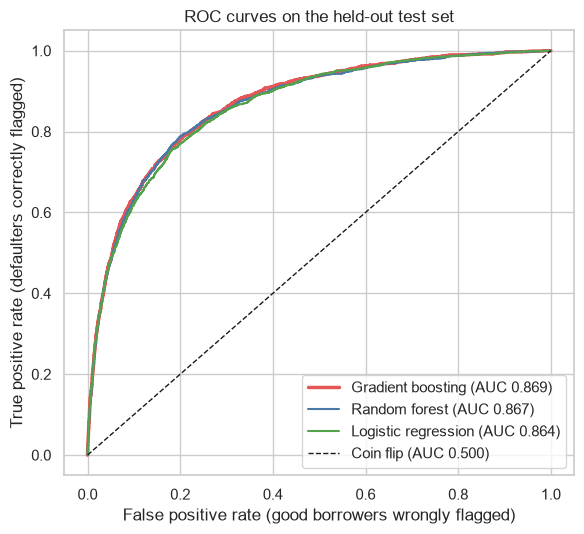

In [4]:
fig, ax = plt.subplots(figsize=(6, 5.5))
styles = {"Gradient boosting": ("#E45756", 2.5), "Random forest": ("#4C78A8", 1.5), "Logistic regression": ("#54A24B", 1.5)}
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y, s)
    color, lw = styles[name]
    ax.plot(fpr, tpr, color=color, lw=lw, label=f"{name} (AUC {roc_auc_score(y, s):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Coin flip (AUC 0.500)")
ax.set_xlabel("False positive rate (good borrowers wrongly flagged)")
ax.set_ylabel("True positive rate (defaulters correctly flagged)")
ax.set_title("ROC curves on the held-out test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/05_roc_curve.png", dpi=150)
plt.show()

**How to read an ROC curve.** Imagine sliding a "flag as risky" cut-off from strict to lenient. Each point on the curve is one cut-off: the horizontal position is the share of *good* borrowers wrongly flagged, the vertical position is the share of *defaulters* caught. A curve hugging the top-left corner is ideal; the dashed diagonal is a coin flip. The area under the curve is the AUC.

In [5]:
# Reference points from Phase 4, now scored on the test set for the same headline comparison
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

inc_age = Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]).fit(X_train[["age", "MonthlyIncome"]], y_train)
ref = pd.Series({
    "Coin flip": 0.5,
    "Logistic on income and age only": roc_auc_score(y, inc_age.predict_proba(X_test[["age", "MonthlyIncome"]])[:, 1]),
    "Rule: rank by total late payments": roc_auc_score(y, X_test.total_late_payments),
    "Gradient boosting (headline model)": roc_auc_score(y, scores["Gradient boosting"]),
}, name="Test AUC")
ref.round(3).to_frame()

,Test AUC
Coin flip,0.500
Logistic on income and age only,0.654
Rule: rank by total late payments,0.780
Gradient boosting (headline model),0.869


On the held-out test set the headline model (0.869) is far above the income-and-age baseline (0.654) and clearly above the "rank by total late payments" rule (0.780).

## 2. Does the model rank risk well? Risk deciles

A concrete way to see ranking quality: sort all 30,000 test borrowers from riskiest to safest according to the gradient boosting score, cut them into 10 equal groups (deciles), and see what share of borrowers in each group actually defaulted.

In [6]:
gb = scores["Gradient boosting"]
dec = pd.DataFrame({"score": gb, "default": y})
dec["decile"] = pd.qcut(dec.score.rank(method="first", ascending=False), 10, labels=range(1, 11))
decile_table = dec.groupby("decile", observed=True).agg(borrowers=("default", "size"), defaulters=("default", "sum"), default_rate=("default", "mean"))
decile_table["share_of_all_defaulters"] = decile_table.defaulters / decile_table.defaulters.sum()
decile_table["cumulative_share_caught"] = decile_table.share_of_all_defaulters.cumsum()
decile_table.round(3)

,borrowers,defaulters,default_rate,share_of_all_defaulters,cumulative_share_caught
decile,,,,,
1,3000,1118,0.373,0.558,0.558
2,3000,353,0.118,0.176,0.734
3,3000,202,0.067,0.101,0.834
4,3000,123,0.041,0.061,0.896
5,3000,74,0.025,0.037,0.933
6,3000,47,0.016,0.023,0.956
7,3000,35,0.012,0.017,0.974
8,3000,32,0.011,0.016,0.990
9,3000,11,0.004,0.005,0.995


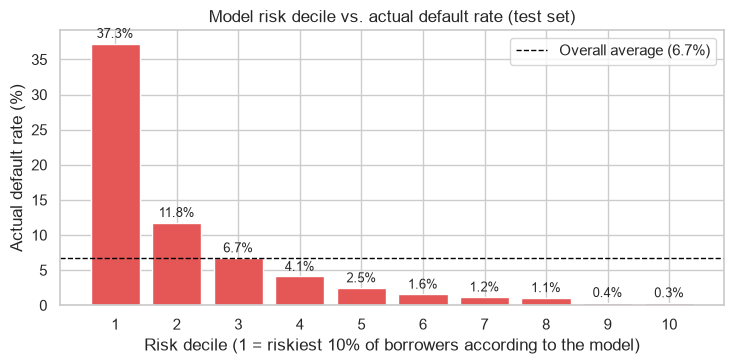

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(decile_table.index.astype(str), decile_table.default_rate * 100, color="#E45756")
ax.axhline(y.mean() * 100, color="black", ls="--", lw=1, label=f"Overall average ({y.mean():.1%})")
for i, v in enumerate(decile_table.default_rate):
    ax.text(i, v * 100 + 0.8, f"{v*100:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Risk decile (1 = riskiest 10% of borrowers according to the model)")
ax.set_ylabel("Actual default rate (%)")
ax.set_title("Model risk decile vs. actual default rate (test set)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/05_risk_deciles.png", dpi=150)
plt.show()

**What this shows.** The ranking is sharp. The riskiest 10% of borrowers defaulted **37.3%** of the time, 5.6 times the overall 6.7%, and contain **55.8%** of all defaulters. The top three deciles contain 83%. The safest 10% defaulted only **0.3%** of the time. The staircase pattern (each decile lower than the last) is what a good risk-ranking model should show.

## 3. Model vs. simple rules (the "rule-based benchmark")

What would a credit officer with no model do? Two plausible hand rules:

- **Rule 1:** flag anyone who has been late on a payment at least once.
- **Rule 2:** flag anyone who has been late **or** is using more than 75% of their credit limit.

For a fair comparison we let the model flag the **same number of borrowers** as each rule (its riskiest N), and see who catches more actual defaulters.

In [8]:
rules = {
    "Rule 1: ever late": (X_test.ever_late == 1).values,
    "Rule 2: ever late OR utilization > 75%": ((X_test.ever_late == 1) | (X_test.RevolvingUtilizationOfUnsecuredLines > 0.75)).values,
}
rows = []
for name, flag in rules.items():
    k = int(flag.sum())
    model_flag = np.zeros(len(y), bool)
    model_flag[np.argsort(-gb)[:k]] = True     # model flags its k riskiest borrowers
    for who, f in [(name, flag), ("   Model, same number flagged", model_flag)]:
        rows.append({"Screen": who, "Borrowers flagged": f.sum(), "% of all borrowers flagged": f.mean() * 100,
                     "Defaulters caught": (f & (y == 1)).sum(),
                     "Recall (% of defaulters caught)": (f & (y == 1)).sum() / y.sum() * 100,
                     "Precision (% of flagged who default)": (f & (y == 1)).sum() / f.sum() * 100})
bench = pd.DataFrame(rows).set_index("Screen")
bench.round(1)

,Borrowers flagged,% of all borrowers flagged,Defaulters caught,Recall (% of defaulters caught),Precision (% of flagged who default)
Screen,,,,,
Rule 1: ever late,5996,20.0,1364,68.0,22.7
"Model, same number flagged",5996,20.0,1471,73.4,24.5
Rule 2: ever late OR utilization > 75%,9139,30.5,1629,81.2,17.8
"Model, same number flagged",9139,30.5,1680,83.8,18.4


**What this shows.** The model beats both hand rules, catching more defaulters for the same number of borrowers flagged, but the margin is modest (about 5 points against "ever late", about 3 against "ever late or heavily utilized"). Simple rules encode most of the signal: this matches the Phase 2 finding that payment history and utilization dominate. The model's extra value comes from weighing all the features together, including age and debt, and from ranking borrowers within the flagged group.

## 4. Choosing the approve/reject cut-off (a business decision)

A model outputs a risk *score*. A bank must turn it into a decision: above some cut-off, flag for rejection or extra checks. Where to draw the line is not a statistics question; it depends on the relative cost of the two mistakes:

- **False negative**: approving a borrower who then defaults. The bank loses money on the loan.
- **False positive**: rejecting or restricting a borrower who would have repaid. The bank loses the interest income and the customer.

Losing principal is usually much worse than losing a margin. We express that as a **cost ratio**: a missed defaulter costs *R* times as much as a wrongly flagged good borrower. **R = 5 is an illustrative assumption, not a fact from the data.** Real values depend on the loan product, recovery rates and interest margins. Below we show how the answer changes for other values.

**No peeking.** To pick the cut-off we use only training data: predictions for each training borrower made by a model that had *not* seen that borrower (cross-validated predictions). The test set is only used to report what happens with the cut-off we already chose.

*Note:* because the models were trained with `class_weight="balanced"`, their scores are not literal probabilities (they run higher than the true default chance). That is fine for ranking and for choosing a cut-off on the score, but "a score of 0.6" does **not** mean "60% chance of default".

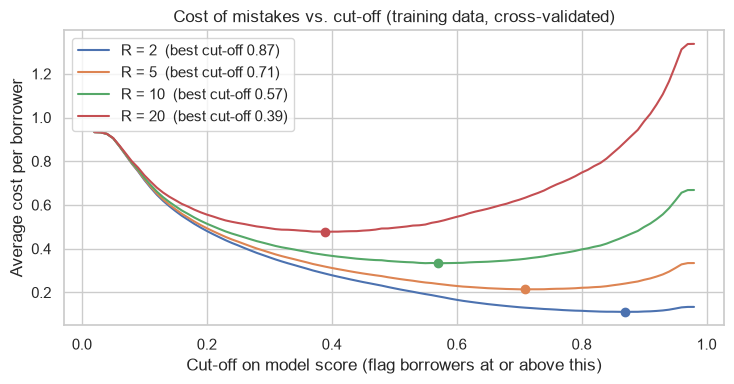

Best cut-off by cost ratio R: {2: np.float64(0.87), 5: np.float64(0.71), 10: np.float64(0.57), 20: np.float64(0.39)}


In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(clone(models["Gradient boosting"]), X_train, y_train, cv=cv, method="predict_proba", n_jobs=5)[:, 1]

grid = np.linspace(0.02, 0.98, 97)
def cost_curve(ratio):
    costs = []
    for t in grid:
        flag = oof >= t
        fn = ((~flag) & (y_train.values == 1)).sum()
        fp = (flag & (y_train.values == 0)).sum()
        costs.append(ratio * fn + fp)
    return np.array(costs) / len(y_train)   # average cost per borrower, in units of "one wrongly rejected good borrower"

ratios = [2, 5, 10, 20]
best_t = {}
fig, ax = plt.subplots(figsize=(7.5, 4))
for r in ratios:
    c = cost_curve(r)
    best_t[r] = grid[np.argmin(c)]
    ax.plot(grid, c, label=f"R = {r}  (best cut-off {best_t[r]:.2f})")
    ax.scatter([best_t[r]], [c.min()], zorder=3)
ax.set_xlabel("Cut-off on model score (flag borrowers at or above this)")
ax.set_ylabel("Average cost per borrower")
ax.set_title("Cost of mistakes vs. cut-off (training data, cross-validated)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/05_threshold_costs.png", dpi=150)
plt.show()
print("Best cut-off by cost ratio R:", {r: round(t, 2) for r, t in best_t.items()})

In [10]:
COST_RATIO = 5            # ASSUMPTION: a missed defaulter costs 5x a wrongly flagged good borrower
THRESHOLD = best_t[COST_RATIO]
print(f"Chosen cut-off (R={COST_RATIO}): {THRESHOLD:.2f}  -- chosen from training data only")

rows = []
for r in ratios:
    t = best_t[r]
    flag = gb >= t
    rows.append({"Cost ratio R": r, "Cut-off": round(t, 2),
                 "% of borrowers flagged": flag.mean() * 100,
                 "Recall": recall_score(y, flag) * 100,
                 "Precision": precision_score(y, flag) * 100,
                 "F1": f1_score(y, flag) * 100})
sens = pd.DataFrame(rows).set_index("Cost ratio R")
print("Test-set results at the cut-off implied by each cost ratio:")
sens.round({"Cut-off": 2, "% of borrowers flagged": 1, "Recall": 1, "Precision": 1, "F1": 1})

Chosen cut-off (R=5): 0.71  -- chosen from training data only
Test-set results at the cut-off implied by each cost ratio:


,Cut-off,% of borrowers flagged,Recall,Precision,F1
Cost ratio R,,,,,
2,0.87,4.8,35.2,49.2,41.1
5,0.71,11.3,58.9,34.9,43.8
10,0.57,19.5,72.9,24.9,37.1
20,0.39,32.5,84.9,17.5,29.0


### Confusion matrix at the chosen cut-off (R = 5)

A **confusion matrix** counts the four possible outcomes when the model's flag is compared with what really happened.

                    Model: not flagged  Model: flagged
Actually repaid                  25798            2197
Actually defaulted                 825            1180

Recall    = 1180/2005 = 58.9%   (of all defaulters, share the model flagged)
Precision = 1180/3377 = 34.9%   (of all flagged borrowers, share who really defaulted)
F1 score  = 0.438   (single number balancing precision and recall)
Flagged   = 11.3% of borrowers; overall default rate is 6.7%


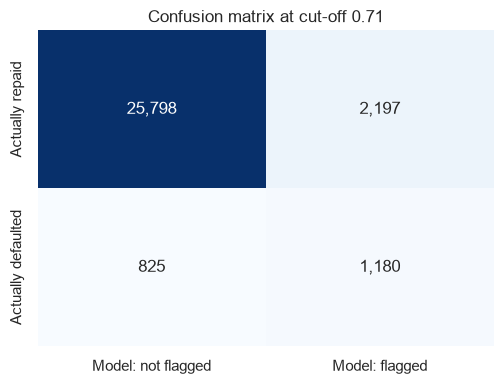

In [11]:
flag = gb >= THRESHOLD
tn, fp, fn, tp = confusion_matrix(y, flag).ravel()
cm = pd.DataFrame([[tn, fp], [fn, tp]], index=["Actually repaid", "Actually defaulted"],
                  columns=["Model: not flagged", "Model: flagged"])
print(cm.to_string())
print()
print(f"Recall    = {tp}/{tp+fn} = {tp/(tp+fn):.1%}   (of all defaulters, share the model flagged)")
print(f"Precision = {tp}/{tp+fp} = {tp/(tp+fp):.1%}   (of all flagged borrowers, share who really defaulted)")
print(f"F1 score  = {f1_score(y, flag):.3f}   (single number balancing precision and recall)")
print(f"Flagged   = {flag.mean():.1%} of borrowers; overall default rate is {y.mean():.1%}")

fig, ax = plt.subplots(figsize=(5.2, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Confusion matrix at cut-off {THRESHOLD:.2f}")
plt.tight_layout()
plt.savefig("../reports/05_confusion_matrix.png", dpi=150)
plt.show()

**In plain words.** Of 30,000 test borrowers, the model flagged 3,377 (11.3%). Of those, 1,180 really defaulted and 2,197 would have repaid. It also missed 825 defaulters. Trade-offs by cost ratio (table above):

- **A lenient screen (R = 20)** flags a third of all borrowers and catches 85% of defaulters, but only 17.5% of flagged borrowers really default, so many good customers get extra checks or are turned away.
- **A strict screen (R = 2)** flags under 5% of borrowers with about 49% precision, but catches only 35% of defaulters.

The cost curve is fairly flat around the minimum for R = 5 (roughly anywhere from 0.55 to 0.85 costs about the same), so this decision is not knife-edge. The cost ratio itself is the thing that needs a business judgment, and it is an assumption here.

## 5. What drives the predictions?

Two complementary views. Both are computed on the test set and neither changes the model.

**View 1: grouped permutation importance.** Shuffle one group of related columns together (breaking their link to the outcome) and see how much AUC drops. A big drop means the model relies on that information. We shuffle *groups* (for example all the payment-history columns at once) because overlapping features would otherwise hide each other: shuffling only `ever_late` barely hurts if `total_late_payments` still carries the same information.

In [12]:
groups = {
    "Payment history (late counts, ever_late, total, code flag)": [
        "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
        "total_late_payments", "ever_late", "past_due_code_flag"],
    "Credit utilization (number + bands)": [
        "RevolvingUtilizationOfUnsecuredLines", "util_25_50", "util_50_75", "util_75_100", "util_over_limit"],
    "Age": ["age"],
    "Income": ["MonthlyIncome", "income_missing_flag"],
    "Debt ratio": ["DebtRatio", "debt_ratio_unreliable_flag"],
    "Number of credit lines / real-estate loans": ["NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines"],
    "Dependents": ["NumberOfDependents", "dependents_missing_flag"],
}
assert sorted(sum(groups.values(), [])) == sorted(X_test.columns), "every feature must be in exactly one group"

base_auc = roc_auc_score(y, gb)
rng = np.random.default_rng(RANDOM_STATE)
imp = {}
for gname, cols in groups.items():
    drops = []
    for _ in range(10):
        Xp = X_test.copy()
        Xp[cols] = X_test[cols].values[rng.permutation(len(X_test))]
        drops.append(base_auc - roc_auc_score(y, models["Gradient boosting"].predict_proba(Xp)[:, 1]))
    imp[gname] = (np.mean(drops), np.std(drops))
imp = pd.DataFrame(imp, index=["AUC drop", "std"]).T.sort_values("AUC drop", ascending=False)
imp.round(4)

,AUC drop,std
"Payment history (late counts, ever_late, total, code flag)",0.1257,0.0025
Credit utilization (number + bands),0.0655,0.0037
Age,0.0094,0.0010
Number of credit lines / real-estate loans,0.0083,0.0007
Debt ratio,0.0035,0.0007
Income,0.0015,0.0003
Dependents,0.0003,0.0001


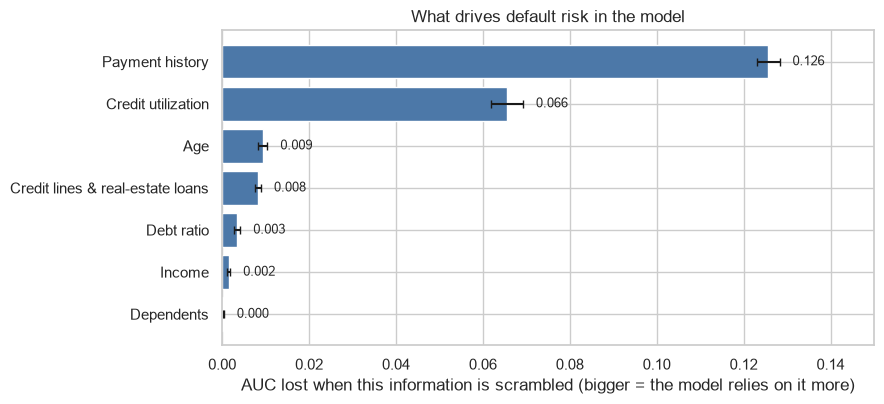

In [13]:
short_names = {
    "Payment history (late counts, ever_late, total, code flag)": "Payment history",
    "Credit utilization (number + bands)": "Credit utilization",
    "Number of credit lines / real-estate loans": "Credit lines & real-estate loans",
}
d = imp.sort_values("AUC drop").rename(index=short_names)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(d.index, d["AUC drop"], xerr=d["std"], color="#4C78A8", capsize=3)
for i, (v, s) in enumerate(zip(d["AUC drop"], d["std"])):
    ax.text(v + s + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 0.15)
ax.set_xlabel("AUC lost when this information is scrambled (bigger = the model relies on it more)")
ax.set_title("What drives default risk in the model")
plt.tight_layout()
plt.savefig("../reports/05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**View 2: SHAP values.** SHAP explains each individual prediction by splitting it into the contribution of every feature (a positive number pushes that borrower's risk up, a negative one pushes it down), based on a fair-division idea from game theory. Averaging the size of these contributions across many borrowers gives a global picture, and the individual dots show *direction*: for example whether high utilization raises or lowers risk. We use a random sample of 4,000 test borrowers to keep it fast.

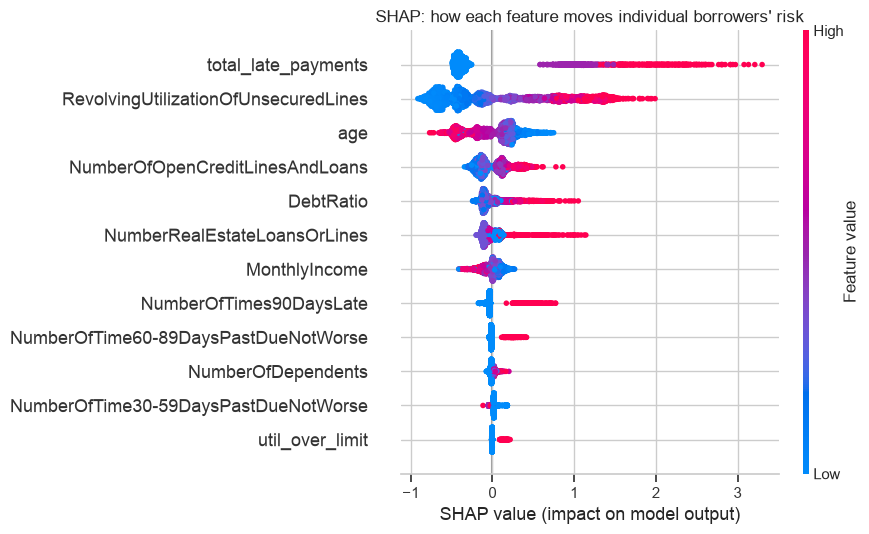

In [14]:
sample = X_test.sample(4000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(models["Gradient boosting"])
sv = explainer.shap_values(sample)
if isinstance(sv, list):      # some versions return one array per class
    sv = sv[1]

shap.summary_plot(sv, sample, max_display=12, show=False, plot_size=(9, 5.5))
plt.title("SHAP: how each feature moves individual borrowers' risk")
plt.tight_layout()
plt.savefig("../reports/05_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Same grouping as above: SHAP contributions are additive, so we can sum them within each group per borrower
sv_df = pd.DataFrame(sv, columns=sample.columns)
grouped = pd.DataFrame({g: sv_df[cols].sum(axis=1) for g, cols in groups.items()})
share = grouped.abs().mean()
share = (share / share.sum() * 100).sort_values(ascending=False).round(1)
print("Share of the model's total 'attention' by group (mean absolute SHAP, %):")
print(share.to_string())

Share of the model's total 'attention' by group (mean absolute SHAP, %):
Payment history (late counts, ever_late, total, code flag)    34.1
Credit utilization (number + bands)                           31.4
Age                                                           12.9
Number of credit lines / real-estate loans                     9.6
Debt ratio                                                     6.7
Income                                                         4.1
Dependents                                                     1.1


**What this shows.** Both views agree on the story. **Payment history and credit utilization dominate** (together about two thirds of the model's attention by SHAP, and about 90% of the AUC lost by permutation). Age, the number of credit lines and debt ratio form a second tier; income and dependents matter very little once the other information is known. The two methods differ on the relative size of payment history vs. utilization (permutation gives history about twice the weight; SHAP gives them roughly equal weight), because they answer different questions: *how much would the model suffer without it* versus *how much does it move predictions*. The SHAP chart above adds direction: higher total late payments and higher utilization push risk up, while older age and higher income push it down.

**A nuance worth noting.** In the SHAP chart, more open credit lines and more real-estate loans push predicted risk *up*, holding everything else fixed. That is different from the raw Phase 2 picture, where the relationship with open credit lines was U-shaped. Combinations of features can reverse a raw relationship (for example, many credit lines together with high utilization), so raw charts and model explanations are answering different questions.

## 6. Where does the model go wrong? (error analysis)

Every model makes mistakes. Understanding them is what a thoughtful analyst adds beyond the headline number. We compare the four groups at the chosen cut-off: caught defaulters (true positives), missed defaulters (false negatives), wrongly flagged good borrowers (false positives), and correctly cleared good borrowers (true negatives).

In [16]:
grp = np.select([flag & (y == 1), (~flag) & (y == 1), flag & (y == 0), (~flag) & (y == 0)],
                ["Caught defaulter (TP)", "Missed defaulter (FN)", "Wrongly flagged (FP)", "Correctly cleared (TN)"], default="")
prof = X_test.assign(group=grp).groupby("group").agg(
    borrowers=("age", "size"),
    pct_ever_late=("ever_late", lambda s: s.mean() * 100),
    avg_total_late=("total_late_payments", "mean"),
    avg_utilization=("RevolvingUtilizationOfUnsecuredLines", "mean"),
    avg_age=("age", "mean"),
    median_income=("MonthlyIncome", "median"),
).loc[["Caught defaulter (TP)", "Missed defaulter (FN)", "Wrongly flagged (FP)", "Correctly cleared (TN)"]]
prof.round(2)

,borrowers,pct_ever_late,avg_total_late,avg_utilization,avg_age,median_income
group,,,,,,
Caught defaulter (TP),1180,96.53,4.22,0.86,43.88,4677.5
Missed defaulter (FN),825,27.27,0.35,0.49,47.28,4900.0
Wrongly flagged (FP),2197,93.04,2.71,0.80,45.40,4750.0
Correctly cleared (TN),25798,10.03,0.12,0.26,53.34,5906.0


**What this shows.**

- **The missed defaulters (825 of 2,005, about 41%) look like ordinary borrowers.** Only 27% of them had ever been late, their average utilization (0.49) is far below that of the caught defaulters (0.86), and they average 0.35 late payments against 4.2 for the ones we caught. Nothing in this dataset warns of them. These are "sudden" defaults (for example job loss or illness), and no model built on these ten columns can see them coming. To reach them a bank would need other information (employment stability, cash-flow data, and so on).
- **The wrongly flagged borrowers (2,197) look almost exactly like real defaulters**: 93% had been late and their average utilization is 0.80. They have the risky profile but repaid anyway. Those cases are a genuine limit of the data, not a bug.
- **The correctly cleared borrowers** are older (average 53), rarely late (10% ever), and use little credit (0.26 on average).
- Roughly speaking, the model is very good at spotting *visible stress* and blind to *unannounced shocks*.

## Phase 5 summary (plain English)

**Headline result.** On 30,000 borrowers the model had never seen, **gradient boosting reaches AUC 0.869 (95% CI 0.861 to 0.878)**. That is in line with the cross-validated 0.864 from Phase 4, so there is no sign of overfitting.

| Screen | Test AUC |
|---|---|
| Coin flip | 0.500 |
| Income and age only (logistic regression) | 0.654 |
| Rule: rank by total late payments | 0.780 |
| Logistic regression (all features) | 0.864 |
| Random forest | 0.867 |
| **Gradient boosting (headline)** | **0.869** |

- **Ranking works well.** The riskiest 10% of borrowers defaulted 37.3% of the time (5.6x the average) and contain 56% of all defaulters. The riskiest 30% contain 83%. The safest 10% defaulted 0.3% of the time.
- **The model beats hand rules, but not by a landslide.** Matching the number of borrowers each rule flags, the model catches 73.4% of defaulters against 68.0% for "ever late" (+5.4 points, about 107 more defaulters), and 83.8% against 81.2% for "ever late or utilization over 75%" (+2.6 points). A simple rule captures most of the signal; the model adds a further, real gain. (There is no manual-underwriting data here, so this is a rule-based benchmark, not a comparison with actual underwriters.)
- **Boosting vs. logistic regression:** boosting is ahead by 0.005 AUC (95% CI 0.003 to 0.008), so the gap is real but small. That is the honest trade-off between accuracy and easy explanation.
- **At the illustrative cut-off (R = 5, cut-off 0.71):** the model flags 11.3% of borrowers, catches **58.9%** of defaulters, and **34.9%** of the flagged borrowers really default (about 5 times the 6.7% average). Confusion matrix: 25,798 correctly cleared, 2,197 wrongly flagged, 825 missed, 1,180 caught.
- **Top drivers:** payment history first, credit utilization second, then age, the number of credit lines, and debt ratio. Income and dependents matter little once the others are known.

### Caveats
- **The cost ratio is an assumption.** R = 5 is illustrative, and the "best" cut-off moves a lot with it (0.87 at R = 2, 0.39 at R = 20).
- **Scores are not probabilities.** Because we trained with balanced class weights, "0.71" does not mean a 71% chance of default.
- **Prediction is not causation.** Utilization and lateness are signals of financial stress, not necessarily causes of default.
- **One dataset, one period.** The result describes this population; it says nothing about another bank, country or economic climate.
- **Fairness.** Age is among the top drivers. Using it (or close proxies) in real lending decisions is legally and ethically sensitive in many places. Phase 6 discusses this.